# Sentiment Analysis

Education
1 'Below College'
2 'College'
3 'Bachelor'
4 'Master'
5 'Doctor'

EnvironmentSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobInvolvement
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

PerformanceRating
1 'Low'
2 'Good'
3 'Excellent'
4 'Outstanding'

RelationshipSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

WorkLifeBalance
1 'Bad'
2 'Good'
3 'Better'
4 'Best'

In [2]:
import pandas as pd
emp_df = pd.read_csv("C:\MyData\Projects\HR Assistant\dataset\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
emp_df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [4]:
Satisfaction_cols = ['JobSatisfaction' , 'EnvironmentSatisfaction','PerformanceRating']
emp_df['Satisfaction'] = emp_df[Satisfaction_cols].mean(axis=1)

In [5]:
def classify_sentiment(score):
    if score >= 4:
        return 'very positive'
    elif score >= 3:
        return 'positive'
    elif score >= 2.5:
        return 'Natural'
    elif score >= 1.5:
        return 'Negative'
    else:
        return 'very negative'

emp_df['Sentiment'] = emp_df['Satisfaction'].apply(classify_sentiment)

In [6]:
emp_df['Sentiment']

0       positive
1       positive
2       positive
3       positive
4       Negative
          ...   
1465    positive
1466     Natural
1467     Natural
1468    positive
1469     Natural
Name: Sentiment, Length: 1470, dtype: object

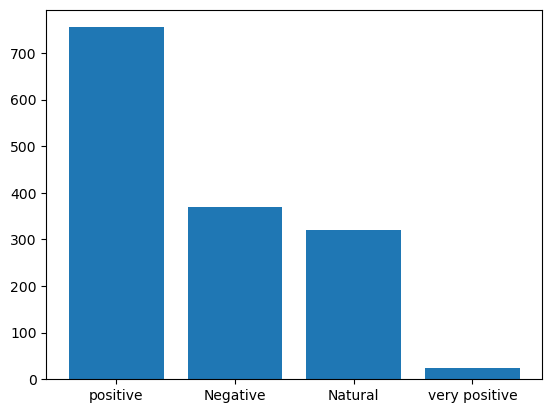

In [7]:
import matplotlib.pyplot as plt 

counts = emp_df['Sentiment'].value_counts()

plt.bar(counts.index, counts.values)
plt.show()

In [ ]:
pip install transformers torch


In [8]:
from transformers import pipeline
# Fast and accurate sentiment model
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

c:\Users\Admin\miniconda3\envs\ai_base\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Admin\miniconda3\envs\ai_base\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administr

In [12]:
def build_employee_text(row):
    satisfaction_map = {1: 'low', 2: 'medium', 3: 'high', 4: 'very high'}
    balance_map = {1: 'bad', 2: 'good', 3: 'better', 4: 'best'}
    return (
        f"My job satisfaction is {satisfaction_map.get(row['JobSatisfaction'], 'unknown')}. "
        f"My environment satisfaction is {satisfaction_map.get(row['EnvironmentSatisfaction'], 'unknown')}. "
        f"My work life balance is {balance_map.get(row['WorkLifeBalance'], 'unknown')}. "
        f"My relationship satisfaction is {satisfaction_map.get(row['RelationshipSatisfaction'], 'unknown')}."
    )
emp_df['EmployeeText'] = emp_df.apply(build_employee_text, axis=1)
print(emp_df['EmployeeText'].iloc[0])

My job satisfaction is very high. My environment satisfaction is medium. My work life balance is bad. My relationship satisfaction is low.


In [13]:
# Run on a sample first to test (full dataset may be slow)
sample = emp_df['EmployeeText'].tolist()
results = sentiment_pipeline(sample, truncation=True, max_length=512)
emp_df['HF_Sentiment'] = [r['label'] for r in results]
emp_df['HF_Score'] = [r['score'] for r in results]
print(emp_df[['EmployeeText', 'HF_Sentiment', 'HF_Score']].head())

                                        EmployeeText HF_Sentiment  HF_Score
0  My job satisfaction is very high. My environme...     NEGATIVE  0.999128
1  My job satisfaction is medium. My environment ...     POSITIVE  0.990737
2  My job satisfaction is high. My environment sa...     NEGATIVE  0.629945
3  My job satisfaction is high. My environment sa...     POSITIVE  0.991325
4  My job satisfaction is medium. My environment ...     NEGATIVE  0.847348


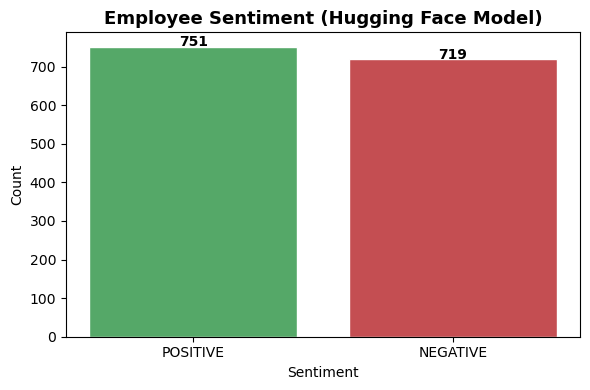

In [14]:
import matplotlib.pyplot as plt
counts = emp_df['HF_Sentiment'].value_counts()
colors = ['#55A868' if label == 'POSITIVE' else '#C44E52' for label in counts.index]
plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             str(int(bar.get_height())),
             ha='center', fontweight='bold')
plt.title('Employee Sentiment (Hugging Face Model)', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()